In [22]:
from sklearn.datasets import make_circles
n= 1000

X,y = make_circles(n, noise= 0.03,random_state= 42)

In [3]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [7]:
import pandas as pd

circles= pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "label": y,})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [10]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

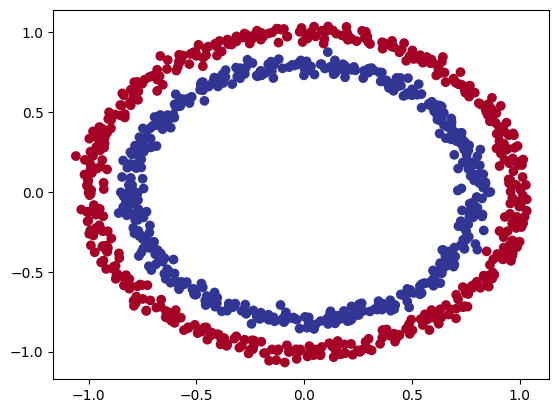

In [11]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu)

In [12]:
X.shape, y.shape

((1000, 2), (1000,))

In [13]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [23]:
import torch
X= torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [26]:
from torch import nn
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [32]:
class CircleModelV0 (nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1= nn.Linear(2,5)
        self.layer_2= nn.Linear(5,1)
    def forward(self,x):
        return self.layer_2(self.layer_1(x))
model_0= CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

In [33]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.4168],
        [-0.7461],
        [ 0.2268],
        [-0.5982],
        [-0.1221],
        [-0.3205],
        [-0.9713],
        [-0.8725],
        [ 0.2405],
        [-0.7721]], device='mps:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [34]:
loss_fn= nn.BCEWithLogitsLoss()

optimizer= torch.optim.SGD(params= model_0.parameters(), lr= 0.1)


In [35]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [37]:
#FLZBO---> forward pass, calculate loss, zero grad, backpropagation on loss, optimizer
torch.manual_seed(42)

epochs=100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_0.train()
    y_logits= model_0(X_train).squeeze()
    y_preds= torch.round(torch.sigmoid(y_logits))

    loss= loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_preds)
    
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72941, Accuracy: 46.75% | Test loss: 0.71350, Test acc: 53.00%
Epoch: 10 | Loss: 0.71676, Accuracy: 47.25% | Test loss: 0.70282, Test acc: 53.50%
Epoch: 20 | Loss: 0.70986, Accuracy: 47.88% | Test loss: 0.69751, Test acc: 53.50%
Epoch: 30 | Loss: 0.70563, Accuracy: 48.62% | Test loss: 0.69464, Test acc: 53.50%
Epoch: 40 | Loss: 0.70282, Accuracy: 48.75% | Test loss: 0.69300, Test acc: 52.50%
Epoch: 50 | Loss: 0.70082, Accuracy: 48.62% | Test loss: 0.69203, Test acc: 52.50%
Epoch: 60 | Loss: 0.69933, Accuracy: 48.88% | Test loss: 0.69144, Test acc: 53.00%
Epoch: 70 | Loss: 0.69819, Accuracy: 48.88% | Test loss: 0.69110, Test acc: 53.00%
Epoch: 80 | Loss: 0.69730, Accuracy: 48.75% | Test loss: 0.69092, Test acc: 53.00%
Epoch: 90 | Loss: 0.69659, Accuracy: 49.00% | Test loss: 0.69084, Test acc: 53.00%


In [38]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

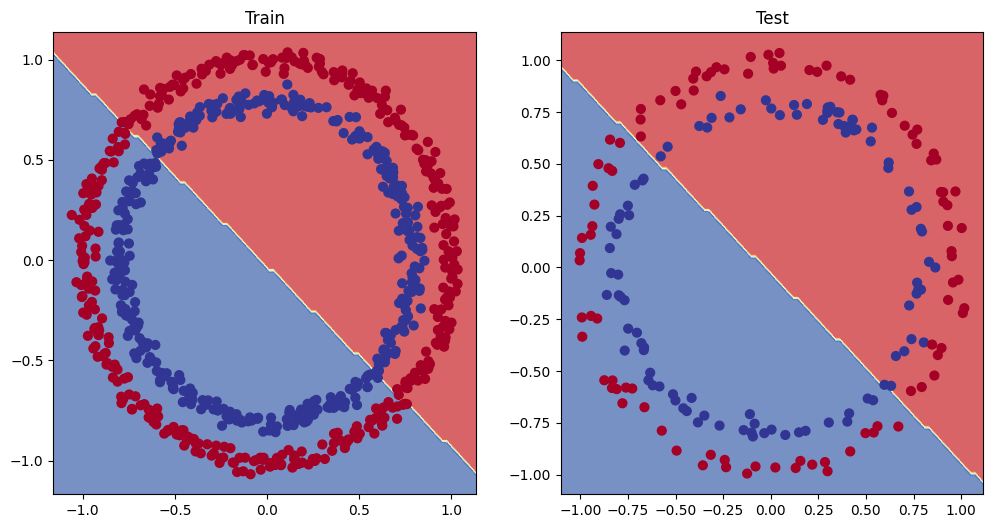

In [39]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [42]:
class CircleModelV2 (nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1= nn.Linear(2,10)
        self.layer_2= nn.Linear(10,10)
        self.layer_3= nn.Linear(10,1)
        self.relu= nn.ReLU()
    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_3= CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [44]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [47]:
#FLZBO---> forward pass, calculate loss, zero grad, backpropagation on loss, optimizer
torch.manual_seed(42)

epochs=1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_3.train()
    y_logits= model_3(X_train).squeeze()
    y_preds= torch.round(torch.sigmoid(y_logits))

    loss= loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_preds)
    
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_3.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_3(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.63630, Accuracy: 83.62% | Test loss: 0.64244, Test acc: 83.50%
Epoch: 100 | Loss: 0.59132, Accuracy: 91.50% | Test loss: 0.60683, Test acc: 87.00%
Epoch: 200 | Loss: 0.50857, Accuracy: 96.38% | Test loss: 0.53906, Test acc: 91.50%
Epoch: 300 | Loss: 0.38100, Accuracy: 98.88% | Test loss: 0.42555, Test acc: 95.00%
Epoch: 400 | Loss: 0.24439, Accuracy: 99.62% | Test loss: 0.29623, Test acc: 98.50%
Epoch: 500 | Loss: 0.43900, Accuracy: 71.00% | Test loss: 0.52714, Test acc: 64.00%
Epoch: 600 | Loss: 0.13214, Accuracy: 99.50% | Test loss: 0.18726, Test acc: 99.50%
Epoch: 700 | Loss: 0.08886, Accuracy: 99.88% | Test loss: 0.13590, Test acc: 100.00%
Epoch: 800 | Loss: 0.07545, Accuracy: 99.62% | Test loss: 0.12772, Test acc: 100.00%
Epoch: 900 | Loss: 0.05416, Accuracy: 99.75% | Test loss: 0.09676, Test acc: 100.00%


In [48]:
# Make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth label

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

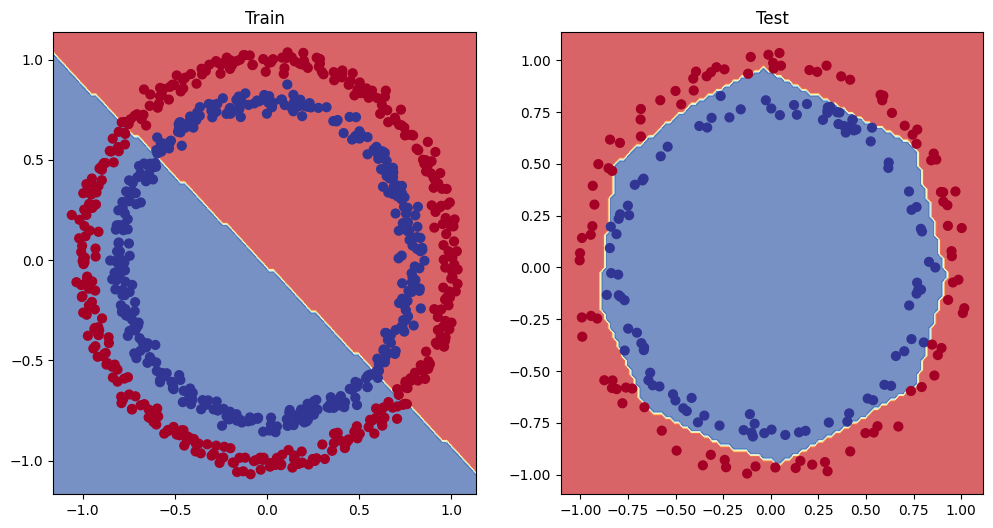

In [49]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity